# Sighin' and M'attitude Errors

Few, if any, numbers can lay claim to stirring up shit for as long as Zero. Wikipedia's article on the [history](https://en.wikipedia.org/wiki/0#History) of zero is fantastic and well worth a late night read. Some cultures embraced it, others used placeholders in lieu of it, and many found it spooky. Cultures, like computers, can wind up flipping out a little when they run into it. 

<p align="center">
  <img src="../../public/assets/img/dividebyzero.gif" alt="Mechanical calculator dividing by zero" />
</p>

Things haven't really changed; and we're still fighting quite a bit over zero just in more nuanced ways. Today's notebook looks at the fight for zero playing out in metascience, for the soul of science. The stakes are high. *What exactly can, should, and has science asked?* 

At the core of today's fight are two papers; one older and the other newer. Both examine how we make mistakes in science, how we quantify those mistakes, and point towards what we perhaps should be doing going forwards. The first, from Gelman and Tuerlinckx [[1]](#ref-1) and later work from Gelman and Carlin [[2]](#ref-2), proposes Sign and Magnitude error as a way of thinking about our errors (alternatively Type-S and Type-M). Roughly Sign errors are when authors claim the direction of an effect is positive when it is negative or vice-versa. Magnitude errors are when the size of the effect is smaller (or larger) than claimed.

I can't say that sign and magnitude errors took off in the literature, but they've been influential. Recently, our own work [[4]](#ref-4) as well as work by others [[5]](#ref-5) has shown that sign error in literature plagued by replication failures can be quite low. In contrast to Ioannidis bold claims from 2005; most of the published literature is correct in the direction of the effects being studied. I wish I felt at liberty to share our peer review from the multiple rounds we've undergone at [journal name redacted] but suffice to say that one of the major complaints we had was we might steal the steam from efforts for reform. 

In any event, our second paper feels a bit of a response to renewed interest in revisiting the literature through the lens of type S and M errors. By way of Daniel Lakens, this piece aims to rein in their limited use [[3]](#ref-3). Behind all of this madness is how we think about zero. Today's blog post is a deep dive into just that, partly because I have a website redesign to test out and partly because I have a new keyboard for the first time in 12 years and it feels fantastic to type on.

You can read the papers first or the blog post first; whichever you prefer. You can find them in the [references](#references) below:




## Hypothesis given the data? Or Data given the hypothesis? 

Today's fight over zero goes back to [Lindley's paradox](https://en.wikipedia.org/wiki/Lindley%27s_paradox); and arguably back to the notion of zero itself (in more ways than one). Chances are when you learned statistics you spent some time errors we ostensibly [make and must balance](https://en.wikipedia.org/wiki/Type_I_and_type_II_errors): Type I and Type II, $\alpha$ and $1-\beta$. They're summarized in these nifty little displays that confuse students until a fleeting "aha" moment and then we sometimes have to google it again to remind ourselves which is which. 

<p align="center">
  <img src="../../public/assets/img/ROC_curves.svg" alt="ROC curve, overlapping class distributions, and confusion matrix courtesy of Wikipedia" style="width: 55%; max-width: 100%; height: auto; margin: 0 auto; background: #fff;" />
</p>

As a refresher, Type I error occurs when the null is true and we mistakenly it and is at the center of our discussion today. Most of the statistical procedures you'll find in any published paper boil down to do the same thing: 

- Assume a value for a parameter, such as an effect of treatment, is exactly zero
  - *Alternatively, subtract and transform some non-zero hypothesis, matrix, etc. until it is zero*
- Given that assumption, calculate the probability of observing data at least as extreme as one did. 
- Report that probability as a $p$-value

Importantly, what we're calculating here is the probability of the Data, assuming a Null hypothesis or $Pr(D \mid H_0)$. Usually what we're interested in scientists, or at least what we talk about is the hypotheses themselves. If we want to know whether a drug works or Youtube radicalizes given the data we've seen, we're asking "What is $Pr( \lnot H_0 \mid D)$?". The math here is just short-hand for the probability ($Pr$) of the null hypothesis ($H_0$) being false ($\lnot$) given ($\mid$) the Data ($D$). 

When we've started discussing this, we now need to think of what other values our effect size or parameter might have. In all but rare case, it's some continuous value; between 0 and 1 or between $-\infty$ and $\infty$. If it's not zero? What's the probability that it is 0.32? or 1? or 12422? Some values are more likely than others. If you'll recall from basic algebra, when we can assign one value in $y$ for every value in $x$ we get a function: 

$$
Pr(x \mid D) = f(x)
$$

You'll notice something important here; namely that our data ($D$) has jumped to the other side of the conditional probability ($\mid$). One of the most important things in all of statistics is that you can't just swap conditional probabilities: $Pr(x \mid D) \neq Pr(D \mid x)$. Doing so gets us into all sorts of trouble and is the source of no shortage of bullshit.  If you need an intuitive example; the probability of someone who is a mass shooter having a diagnosable mental illness is high. The probability of someone with a diagnosable mental illness engaging in a mass shooting is low. These are different numbers; and you need [Bayes' theorem](https://en.wikipedia.org/wiki/Bayes%27_theorem) to get from one to the other. Perhaps soon I'll post about my TB or not TB saga during hospitalization, where Bayes theorem and decision-theory had a war, leaving me in a negative air-pressure room for two weeks over what was clearly a false positive. 

In any event, below is a very silly illustrative example of how we might analyze a simple RCT if we wanted to wind up sampling from $Pr(x | D) = f(x)$, where $f(x)$ tells us how likely different treatment effect sizes might be. It uses [PyMC](https://www.pymc.io/) and [ArviZ](https://python.arviz.org/), two lovely Python libraries for Bayesian modeling and posterior visualization.

NUTS[nutpie]: [beta, sigma]


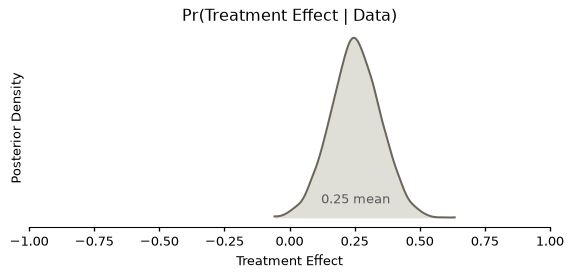

In [1]:
import pymc as pm
import numpy as np
import arviz as az
import matplotlib.pyplot as plt


#Wada warm greys for life, y'all 
WADA_LINE = "#6b6659"
WADA_FILL = "#b8b6a8"

#The answer to life, the universe and everything else is setting the seed. 
np.random.seed(42)
#Define the data; assume we have some 200 participants in a study
#and treat half of them at random; which has a treatment effect of 0.32
n = 200
true_effect = 0.16
treated = np.random.binomial(1, 0.5, n)
delta = np.random.normal(true_effect * treated, 1, n)

#This is our statistical model; we're assuming a normal distribution for the effect size
#and a half-normal distribution for the standard deviation. 
with pm.Model():
    beta = pm.Normal("beta", mu=0, sigma=1)
    sigma = pm.HalfNormal("sigma", sigma=1)
    pm.Normal("delta", mu=beta * treated, sigma=sigma, observed=delta)
    idata = pm.sample(1000, progressbar=False)

#This is just some plotting code. 
az.plot_dist(
    idata,
    var_names=["beta"],
    kind="kde",
    visuals={
        "dist": {"color": WADA_LINE, "linewidth": 1.5},
        "face": {"color": WADA_FILL, "alpha": 0.45},
        "credible_interval": False,
        "point_estimate": False,
    },
)
plt.xlim(-1, 1)
plt.xlabel("Treatment Effect")
plt.ylabel("Posterior Density")
plt.title("Pr(Treatment Effect | Data)")
plt.show()

from IPython.display import Markdown, display

sign_pct = (idata.posterior["beta"] < 0).mean().item() * 100

## If a zero falls on a point does it have a mass? 

If the idea of just plotting likely values of effect sizes rather than science via tables of $p$-values and coefficients appeals to you; [click here](https://xcelab.net/rm/). That said, when we start thinking about science as $Pr(x \mid D)$ we wind up confronting an uncomfortable truth. Earlier we had to remember a core idea from algebra (functions) and now we've got to remember a core idea from calculus:

$$
\int_a^a f(x)\,dx = 0
$$

If we take an integral from some point, $a$ to that same point $a$, the area under the curve will be infinitely small... it will be *0*. As a result, the probability of any point-null hypothesis (the kind most scientists test most of the time) is 0. This leads to an uncomfortable conclusion: we should *always* reject point null hypotheses of the sort $H_0: x \equiv 0$...the kind nearly every published study is testing. In other words, we never have to make a Type I error or Type II error; just set $\alpha=1$ and reject every point null hypothesis. 

Of course this is remarkably unsatisfying, feels very smug-Bayesian, and doesn't tell us how to use science to do anything of value. It's at best a *reductio ad absurdum* to highlight something wrong about our intuitions with point-null hypothesis testing and Type I/II error. It's this tension is exactly what motivates the sign/magnitude framing [[1]](#ref-1), [[2]](#ref-2) and its recent pushback [[3]](#ref-3).


### Sign Error
Instead of a fixed point, we could ask something like the probability that X is less than zero, given the data: $Pr(x < 0 \mid D)$. In our silly little example above, it's the mass of that distribution that is below zero. In this case of our silly example above it winds up being around `{python} round(sign_pct, 1)`%. To me this is an important scientific question that we're often confronted with... what's the chance that a drug makes patients worse? The chance that youtube deradicalizes rather than radicalizes? Zero has this uncanny property whereby a lot of decisions we'd make in the real world hinge on something like sign.

In the original work by Gelman & Tuerlinckx [[1]](#ref-1), they incorporate the fact that we often have some threshold, such as $p<.05$, that we require before making a "claim with confidence." Let's call that $d_{crit}$. It's the critical value for our test statistic or effect size that we'd need to observe before we'd go from saying "Idk" to rejecting "IDK" and tentatively making a claim of "it's positive" or "it's negative". Type S error is the chance that it's *actually* negative, given that we've made a claim it's positive $Pr(x < 0  \mid d_{obs} > d_{crit})$. This is a lovely little figure showcasing those possibilities. 

<p align="center">
  <img src="../../public/assets/img/type-s-error-gelman-tuerlinckx-2000.png" alt="Type S error regions from Gelman &amp; Tuerlinckx (2000)" style="width: 60%; max-width: 100%; height: auto; margin: 0 auto;" />
</p>

The paper goes on to ask, and examine, how Bayesian and classical statistical approaches in the context of the hierarchical model differ. To avoid being too bogged down in the details here, the key thing is that they show sign error rates are quite different as signal to noise, or power increases. When things are very close to the null being "true"; the sign error rates for Bayesian procedures will be lower than for analogous classical approaches. The reason is nothing magical, simply that the Bayesian approach winds up being more conservative on the left half of the graph and almost never winds up supporting a claim with confidence. 


<p align="center">
  <img src="../../public/assets/img/type-s-error-rate-classical-vs-bayes.png" alt="Conditional Type S error rate vs τ/σ for classical and Bayes procedures (Gelman &amp; Tuerlinckx, 2000)" style="width: 45%; max-width: 100%; height: auto; margin: 0 auto;" />
</p>

That said the meat and potatoes of the paper is here, and relates to multiple comparisons and possesses my favorite little typo: 

>In particular, the dramatically high Type S error rates of classical procedures when τ is near zero suggests that, for the purposes of inference (as opposed to testing), control over Type 1 errors—in either the single or multiple comparisons case—does not necessarily mean that statistically significant claims are reliable. This casts some doubt on those statistical procedures if in some cases half of the classical comparisons are false in the sense of having the wrong sing.

In essence, G&T point out that in contexts where our power to detect effects is low; the typical approach to science of $P<.05$ provides us no real assurances we aren't just flipping a coin about the directional claims we're making. Especially in literatures selected for significance, this winds up with *noise*. However, if we start thinking about Type-S error we can select for procedures and approaches that get us lower rates of error; if error in direction is what we care about. They go on: 

>The purpose of this paper, however, is not to make a claim that Bayesian intervals are better or worse than classical intervals... Rather, we demonstrate that the Type S error rate—which we argue is the relevant error rate for statistical analyses in the social and behavioral sciences—differs dramatically from the Type 1 error rate, which is usually used to calibrate interval estimation procedures

## Slippin' on G&T

So where does the debate come in? 

In "Rethinking Type S and Type M errors", a team of authors (LMXRTA for short) take to task the notions of Type-S and Type-M errors with a few different lines of argumentation. The first of which is somewhat summarized here, where they consider the case where the null is *approximately* true. They write: 

>If there is an infinitesimally small positive effect, the statistical power of the test is practically indistinguishable from the alpha level of .05. Effects will be rejected in the positive direction with a probability of .025 in the long run (correct rejections), and effects will be rejected in the negative direction with a probability of .025 in the long run (Type S errors). The only difference between a Type S error and a Type 1 error in this scenario is that Gelman and Tuerlinckx removed the value of 0 from the distribution of possible effect sizes

Remember earlier where I said one of the most important things in statistics is you can't just switch around conditional probabilities? Well you certainly can't replace them with unconditional probabilities. G&T are concerned with the conditional probability of $Pr(\text{Wrong Sign} \mid \text{Claim})$. This is different from Type I error which would be $Pr(\text{Wrong Sign}, \theta = 0)$ for a directional test. Here, $\theta$ is the unknown true effect.

For a classical statistical test, as LMXRTA are considering, G&T are interested in $Pr(d_{obs} <0 \mid P<.05, \theta > 0) \approx 0.5$. Conditional on obtaining a statistically significant result, what is the probability that the observed direction, and therefore the directional claim, is wrong? It's 0.5, as seen on the far left side of the second image from their paper above. It's an entirely different estimand from the wrong-tail if $\theta$ is tiny technically-not-Type-I-error which is 0.025. In other words, G&T are asking "Among the significant claims in the literature, how many are in the wrong direction?" It's agnostic to the effect size, but when you set it near zero it still isn't (wrong-direction, small $\theta$) Type I error; which asks "How often will I make a claim, and do so in the wrong direction?"  

Now what's weird to me about this section is later they seem to sort of get this conditional dependence; and make the same argument but here to say that Type S is basically the same thing (In these very strict conditions) as the False Discovery Rate (FDR): 

> In the infinitesimal-effect case, the statistical power of the test is .05, and the Type S error is .025, so the rate of Type S errors as a proportion of significant results is .025 / .05 = .5. In the extreme case in which power is as low as the alpha level, 50% of significant results are sign errors.... This conditional probability is similar to the false-discovery rate, which is the expected proportion of false positives among all positive findings.

Here too, we have very different estimands. FDR is the expected rate of true discoveries to false discoveries; but doesn't necessarily have a directional component to it. If you modify FDR so that a "false discovery" means a discovery in the wrong direction rather than a discovery under a true null, you have essentially constructed a directional false-discovery measure that is conceptually the same as a Type S error rate. This seems to be what LMXRTA have done, only to claim that a modified FDR being the same as Type S means that Type S is just the same thing as FDR in general. 

*But each of these examples of conflated estimands miss the point*: In either case, LMXRTA are driving $\theta$ to near zero and then highlighting only the behavior of classical statistical models controlling Type I error. They then rediscover many of the things that G&T explicitly point out, such as the 50% Type-S error in low-signal regimes for classical procedures. G&T use Type S error to point out that controlling for Type I error can lead to lots of sign error, and that Type-S can reveal how procedures with identical receiver operating characteristics (ROC) nonetheless differ in their ability to ask a common scientific question: Did we get the direction of the effect right? 


### Never say never, say negligible instead. 

The other big objection LMXRTA make is that G&T err in saying that the point-null hypothesis is never going to be true. First up, they cite some dudes who feel differently which to me isn't a particularly compelling argument. Then there's this gem: 

> Neither side can provide empirical support for or against the hypothesis that the null hypothesis is never true because one cannot measure the entire population for all effects scientists want to study. The claim that the null is never true is scientifically unfalsifiable. 

I don't think this is a question so much of measuring every single effect size without error and checking one by one to see if they're exactly zero. As noted above, it's just basic calculus that the area under the curve at a point is zero. If we're asking $Pr(\theta \mid D)$, and $\theta$ is a continuous parameter of interest then for most reasonable cases we're going to wind up with zero mass at zero, or at 123, or at 14.2 (or any specific place). 

When scientists do measure things that churn near-perfect nulls, we usually wind up learning or confirming physics. [Millikan's oil drop](https://en.wikipedia.org/wiki/Oil_drop_experiment) experiment is a fun example where integer multiples of a constant start popping out because electrical charge is quantized. Although it's sort of a funny example, because there was some alleged data smoothing and very sociological dynamics of measurement that played out over time. Give the fully wiki a read if you get quite bored. In any event, the only real way to get precisely zero or some other to have some non-zero mass is to have some discontinuity in the generative process. If there are examples in the social sciences where you can conceive of a mechanistic model that gets us these kinds of discontinuities, I'm all ears. 

The article goes on to suggest that authors should, instead, test against the smallest effect sizes of interest (SESOI) after running a power analysis. What's interesting here is that Type S error, in its original 2000 G&T argumentation, was designed to show that merely controlling for type I error with a point-null can leave us with a lot of claims with confidence in the wrong direction. The Bayesian approach in the paper winds up a bit more conservative than classical point-nulls, effectively setting up a soft filter against claims when effect sizes are small---it's a smooth version of the SESOI. G&T's whole argument is that something like Type S can help us decide if that's right for us, and... ironically... could be used to justify SESOI over a point null. 

We'll get into the magnitude error stuff another day, but for now I think it's important to return to why Sign errors matter. 

## Why it matters

This blog post is getting long, and we've gotten into the weeds about Type-S errors. I'm not quite sure what the motivation of LMXRTA in writing their piece, but it's unfortunate they got so turned around on estimands and integration of continuous functions. The rest of the G&T piece, as well as subsequent work, is somehow quite complementary with a lot of the work folks like Lakens' have done; and provides a reasonable means of evaluating the trade-offs one hits when setting something like an SESOI. 

Here's one example from our work [[4]](#ref-4). In the Supplement we look at sign/magnitude error trade-offs when increasing sample size. You can also think of increasing sample size here as roughly decreasing your SESOI, because larger samples allow for detection of smaller effects. Either way, we find that if your sample size is small you wind up generally making claims in the right direction. However, you almost always wind up inflating their magnitude by a fair deal. Increasing sample size decreases the inflation; but does so at a cost of more sign errors in the claims you make. It's a proper trade-off that we wouldn't expect if we're just thinking about Type I and Type II error. 

<p align="center">
  <img src="../../public/assets/img/sign-magnitude-error-vs-sample-size.png" alt="Pr(Sign Error) and Magnitude Error vs sample size for post-hoc α levels" style="width: 75%; max-width: 100%; height: auto; margin: 0 auto;" />
</p>

This brings us to why it *really* matters that we don't throw these babies out with the bathwater. As we find in our paper below, and has been independently arrived at by van Zwet, sign errors in the literature (most of it, per van Zwet) are pretty low. Underpowered studies believed to be a scourge actually wind up filtering out quite a lot of claims that might be made in the wrong direction.

In essence, frugality or whatever it is that drives social sciences and other disciplines to conduct research with ostensibly inadequate sample sizes may have resulted in a literature that is exaggerated in magnitude but essentially correct in direction. These are the kind of things we can only reveal if we're willing to think about various estimands for error. Whether this is good or bad is something we can only even begin to debate once we've seen it, through the proper estimands. 

## Concluding thoughts 
I read (ok skimed) the rethiking Type-S and Type-M paper while in the hospital and it's been rummaging around in my brain ever since. While it was clear the authors were quite turned around about what Type-S error is, but I don't think that alone warrants a blog post... I'd never get any sleep. I think the deeper issue it raises is a need within metascience to think more broadly and clearly about estimands. The response from LMXRTA seems to be typical "use my methods, not your methods." The G&T paper, by contrast, was a metascientific paper--asking what we would expect the literature to look like under various scenarios for decision-making in science. 

In this sense, it was ahead of its time; and remains so perhaps. It asks... what is it that science is trying to measure? What is metascience trying to measure about science? Twenty six years later it lest us ask: is a literature full of claims in the right direction sufficient to build knowledge? Or do we need the magnitudes to be well-calibrated? When trade-offs exist, which do we prefer? When we set up a rule; like $P<.05$, what effect does it have on other estimands--Type S and Type M are just two of infinitely many. How do these questions and their answer vary across and within disciplines? 

I hope to see metascience pivot in this direction and away from measuring replicability a bakers dozen different ways and then averaging them into the same 50% scare statistic, I also hope to see metascientists being less concerned about the one-right-method for doing things and more curious about the questions we might ask in science and how we might go about answering them.  


I think I've run dry on time to dedicate to bloging today and decided the keyboard is worth keeping... but let me know what you think on bluesky or via an angry email. 




<a id="references"></a>

## References

<p id="ref-1"><strong>[1]</strong> Gelman, A., & Tuerlinckx, F. (2000). Type S error rates for classical and Bayesian single and multiple comparison procedures. <em>Computational Statistics</em>, 15(3), 373–390. <a href="https://doi.org/10.1007/s001800000040">doi:10.1007/s001800000040</a></p>

<p id="ref-2"><strong>[2]</strong> Gelman, A., & Carlin, J. (2014). Beyond power calculations: Assessing type S (sign) and type M (magnitude) errors. <em>Perspectives on Psychological Science</em>, 9(6), 641–651. <a href="https://sites.stat.columbia.edu/gelman/research/published/retropower_final.pdf">PDF</a></p>

<p id="ref-3"><strong>[3]</strong> Lakens, D., Mesquida, C., Xavier-Quintais, G., Rasti, S., Toffalini, E., & Altoè, G. (2026). Rethinking Type S and Type M Errors. <em>Advances in Methods and Practices in Psychological Science</em>, 9(2). <a href="https://journals.sagepub.com/doi/full/10.1177/25152459261432530">doi:10.1177/25152459261432530</a></p>

<p id="ref-4"><strong>[4]</strong> Bak-Coleman, J. B., Mann, R. P., Bergstrom, C. T., Gross, K., & West, J. (2022). Replication, varying effects, and the reliability of the scientific literature. SocArXiv. <a href="https://osf.io/rkyf7">osf.io/rkyf7</a></p>

<p id="ref-5"><strong>[5]</strong> van Zwet, E., Gelman, A., & Więcek, W. (2026). A Statistical Case for Qualified Scientific Optimism. Unpublished manuscript. <a href="https://sites.stat.columbia.edu/gelman/research/unpublished/A_statistical_case_for_qualified_scientific_optimism.pdf">PDF</a></p>